# MODEL COMPARISONS BY MODELS + SEGMENTS

In [3]:
# Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from pathlib import Path

RESULTS = Path('/Users/xaviersun/UNSW_Projects/ZZSC9020-group-A/results')

In [5]:
NAMES = {'lightgbm': 'LightGBM', 'lstm': 'LSTM', 'xgboost': 'XGBoost',
         'random_forest': 'Random Forest', 'prophet': 'Prophet', 'baseline': 'Baseline (LR)'}
SEGMENTS = {'Summer': 'Summer', 'Autumn': 'Autumn', 'Winter': 'Winter', 'Spring': 'Spring',
            'above_18': 'Temp 18°C and above', 'below_18': 'Temp below 18°C'}

seg = pd.read_csv(RESULTS / 'model_comparison_by_segment.csv')
seg['Model'] = seg['model_name'].map(NAMES)



In [6]:
# Primary results are the runs that include radiation_day_before
main = seg[seg.with_radiation].copy()
ORDER = (main[main.segment == 'overall'].sort_values('mae')['Model'].tolist())

## Accuracy by Segment

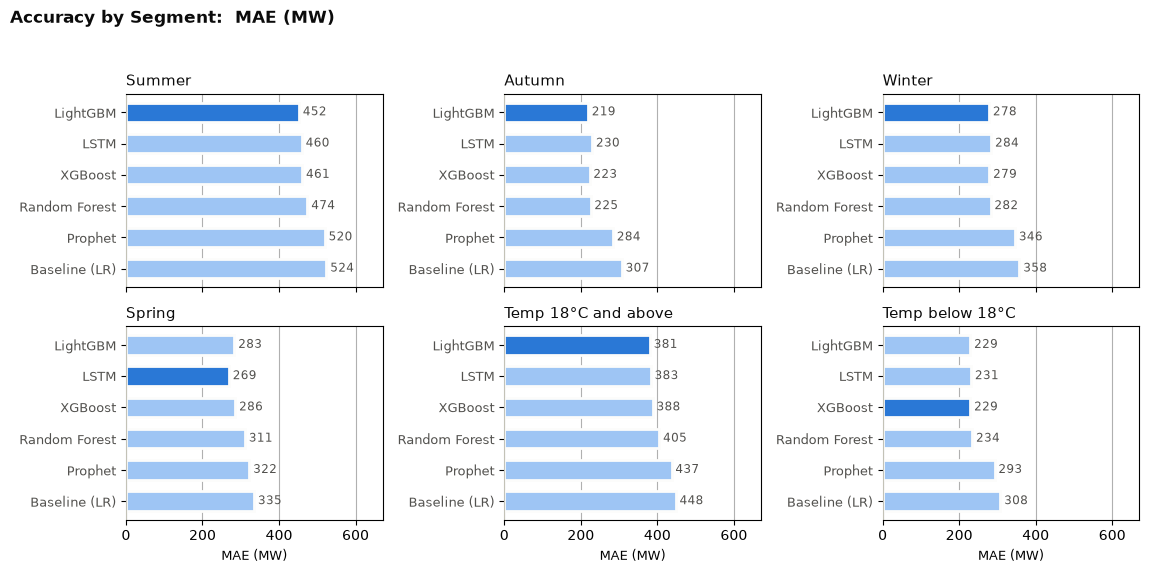

In [10]:
# Figure: the same ranking across every segment
panels = list(SEGMENTS)
fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.8), sharex=True, facecolor='w', edgecolor='k')

for ax, s in zip(axes.ravel(), panels):
    d = main[main.segment == s].set_index('Model').loc[ORDER]
    y = np.arange(len(d))[::-1]
    ax.barh(y, d['mae'], height=0.62,
            color=['#2a78d6' if m == d['mae'].idxmin() else '#9ec5f4' for m in d.index],
            edgecolor='#fcfcfb', linewidth=2)
    for yi, v in zip(y, d['mae']):
        ax.text(v + 10, yi, f'{v:,.0f}', va='center', fontsize=8.5, color='#52514e')
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=9, color='#52514e')
    ax.set_title(SEGMENTS[s], fontsize=10.5, loc='left', color='#0b0b0b', pad=6)
    ax.xaxis.grid(True, linewidth=0.8); ax.set_axisbelow(True)
    ax.spines['left'].set_color('#c3c2b7')

ax.set_xlim(0, main[main.segment != 'overall']['mae'].max() * 1.28)
for ax in axes[1]:
    ax.set_xlabel('MAE (MW)', fontsize=9.5)
fig.suptitle('Accuracy by Segment:  MAE (MW)',
             fontsize=12.5, fontweight='bold', x=0.005, ha='left', color='#0b0b0b')
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## The Radiation Feature:  With vs. Without

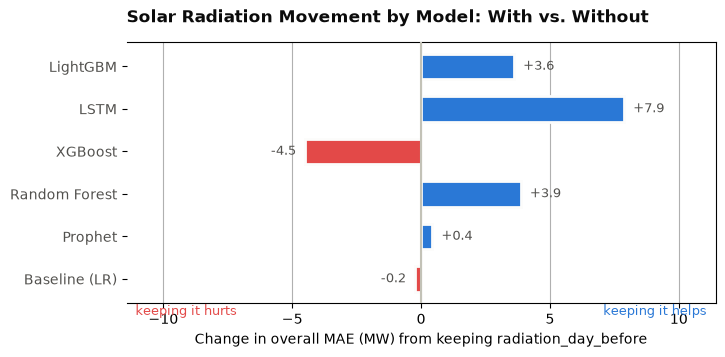

with_radiation  MAE with  MAE without  gain
Model                                      
LightGBM          307.40       311.01  3.61
LSTM              309.33       317.21  7.88
XGBoost           311.18       306.67 -4.50
Random Forest     322.45       326.32  3.87
Prophet           367.34       367.77  0.44
Baseline (LR)     380.22       379.97 -0.24


In [16]:
# Figure: does `radiation_day_before` change anything?
rad = (seg[seg.segment == 'overall']
       .pivot_table(index='Model', columns='with_radiation', values='mae'))
rad['gain'] = rad[False] - rad[True]       # positive = keeping radiation lowers MAE
rad = rad.loc[ORDER]

fig, ax = plt.subplots(figsize=(7.6, 3.4))
y = np.arange(len(rad))[::-1]
ax.barh(y, rad['gain'], height=0.6,
        color=['#2a78d6' if g > 0 else '#e34948' for g in rad['gain']], edgecolor='#fcfcfb', linewidth=2)
ax.axvline(0, color='#c3c2b7', linewidth=1.5, zorder=3)

for yi, g in zip(y, rad['gain']):
    off = 0.35 if g >= 0 else -0.35
    ax.text(g + off, yi, f'{g:+.1f}', va='center', fontsize=9.5, color='#52514e',
            ha='left' if g >= 0 else 'right')

ax.set_yticks(y); ax.set_yticklabels(rad.index, fontsize=10, color='#52514e')
ax.set_xlabel('Change in overall MAE (MW) from keeping radiation_day_before')
lim = np.abs(rad['gain']).max() * 1.45
ax.set_xlim(-lim, lim)
ax.xaxis.grid(True, linewidth=0.8); ax.set_axisbelow(True)
ax.spines['left'].set_visible(False)
ax.text(lim * 0.97, y[-1] - 0.85, 'keeping it helps', color='#2a78d6', fontsize=9, ha='right')
ax.text(-lim * 0.97, y[-1] - 0.85, 'keeping it hurts', color='#e34948', fontsize=9, ha='left')
ax.set_title('Solar Radiation Movement by Model: With vs. Without',
             fontsize=12.5, fontweight='bold', loc='left', pad=14, color='#0b0b0b')
plt.show()

print(rad[[True, False, 'gain']].rename(columns={True: 'MAE with', False: 'MAE without'})
        .to_string(float_format=lambda v: f'{v:,.2f}'))